In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os, importlib, h5py
from scipy.interpolate import CubicSpline


#Define if needed and ADAPT (should point towards folder where jaxions git sits!)
#os.environ['JAXIONS_DIR'] = '/Users/mathieu/Salsa/jaxionsdir/'

# Get JAXIONS_DIR
jaxions_dir = os.environ.get("JAXIONS_DIR")
if not jaxions_dir:
    raise EnvironmentError("Please set the JAXIONS_DIR environment variable first.")


scripts_path = os.path.join(jaxions_dir, "jaxions/scripts")

# Add it to Python module search path
if scripts_path not in sys.path:
    sys.path.insert(0, scripts_path)
    
#find the correct modules
from tools import kin_mis_utils as km
plt.style.use('plots.mplstyle')

# Generic Evolution

We can run simple 1D simulations of the cosmological evolution (in conformal time) of the axion field given some initial value and velocity. 

In [2]:
π = np.pi 

#specify conformal time grid + ICs
τ = np.linspace(1,5,1000)

θ_init = 1.
v_init = 2.8e2

fA = 1e10 #GeV!

#Run 1D evolution
result = km.evolution_kinetic_mis(fA, θ_init, v_init, τ)

In [3]:
#check what is stored
result.keys()

dict_keys(['fAGeV', 'mAMeV', 'T1MeV', 'H1MeV', 'R1', 'TMeV_trap', 'HMeV_trap', 'R_trap', 'mAMeV_trap', 'grhotab', 'gstab', 'TMeVtab', 'thetatab', 'vhetatab', 'Omegah2tab'])

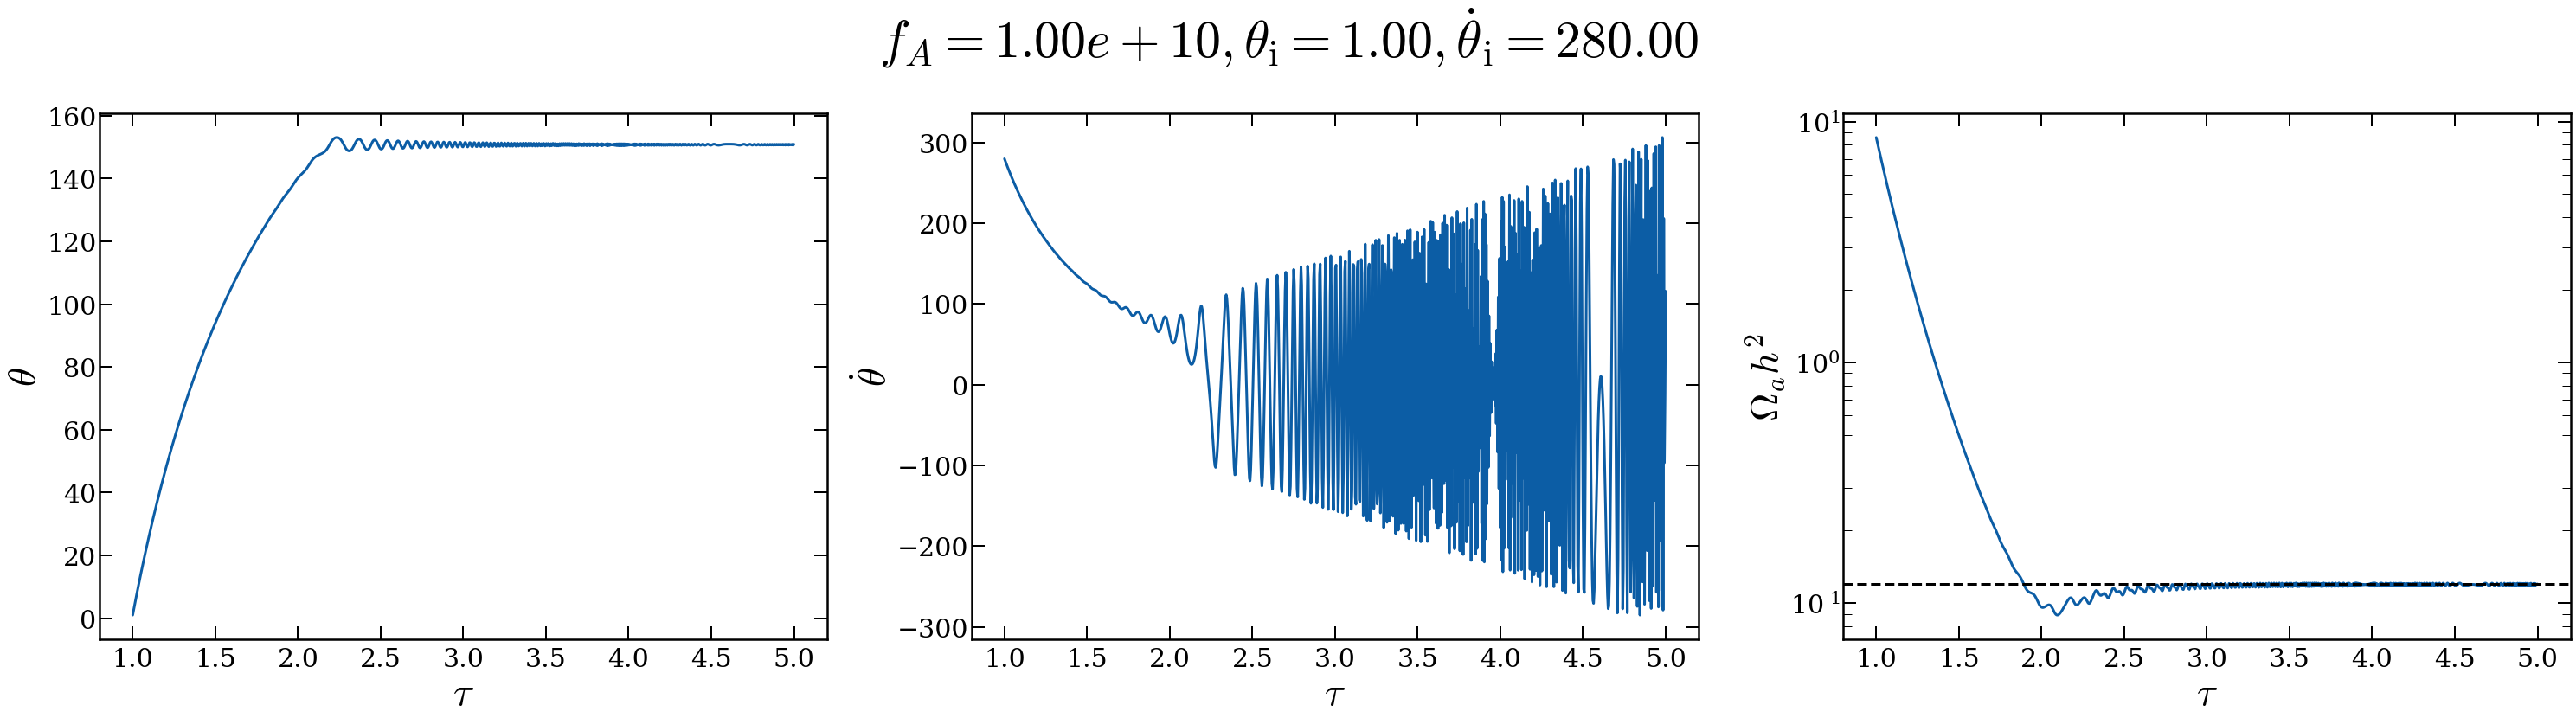

In [4]:
fig, ax = plt.subplots(1,3,figsize=(42,12))

#theta
ax[0].plot(τ,result['thetatab'])
ax[0].set_ylabel(r'$\theta$')

#v
ax[1].plot(τ,result['vhetatab'])
ax[1].set_ylabel(r'$\dot\theta$')

#abundance
ax[2].semilogy(τ,result['Omegah2tab'])
ax[2].axhline(0.12, color = 'k', ls = '--')
ax[2].set_ylabel(r'$\Omega_a h^2$')

for a in ax:
    a.set_xlabel(r'$\tau$')

plt.suptitle(r'$f_A = %.2e, \theta_{\rm i} = %.2f, \dot{\theta}_{\rm i} = %.2f$'%(fA, θ_init, v_init), fontsize=60)
plt.tight_layout()
plt.show()

# Finding the right ICs: Parameter Matches

For most practical cases, we are only interested in choosing initial conditions that give the total observed DM abundance, i.e. $\Omega_a h^2 = 0.12$. This little helper tool allows us to find ICs that match this criterion within a given tolerance.

In [ ]:
vrange = np.logspace(-2,2,4)

matches = km.find_params(fA, τ, vrange, target = 0.12, tol = 0.01)

`tools/theta_vheta_match.py`

An executable Python script for this task is available at:

`tools/theta_vheta_match.py`

### Usage

You can customize the input parameters directly in the script:

```python
# Input
vheta1_range_list = [(10, 11, 1.0)]  # Define vheta1 ranges and steps
fAGeV = 1e10  # Axion decay constant in GeV
```

After editing these values, run the script from your terminal:

`python tools/theta_vheta_match.py`

### Output

The script will generate JSON files containing the corresponding
parameter matches.

Notes

-   The computation is parallelized across all available CPU cores on
    your machine, allowing for efficient processing.


# Generating initial spectrum file for full 3D $\texttt{jaxions}$ simulations 
To run proper 3D simulations of this scenario using the jaxions code, we need to prepare an initial spectrum. Besides the ICs we also provide for the 1D simulation, we need to define the simulation box specifications for the jaxions simulation as well, in order to correctly define the initial spectrum.

In [5]:
N = 64 #Number of grid points per dimension (for now same in x,y,z, i.e. N^3 points in total)
L = 3. # Size of the box (simulation box volume = L^3)


k, m, v = km.genspec_kinetic_mis (N, L, θ_init, v_init, hom = True)

This created a txt file "initialspectrum.dat", that should be moved into the correct working directory, where you want to launch the simulation. For a tutorial on how to set up and run $\texttt{jaxions}$, we refer to the respective git repo (https://github.com/veintemillas/jaxions) or the manual (currently in preparation!)